## Validación del proceso de Machine Learning

### Proyecto:
Pacientes con problemas de hígado - India

**Autor:** Mariana Bedoya Arismendy

### Fecha:
2026-08-19

### Incidencia:
12 - Selección del mejor modelo

### Descripción:

Este notebook valida el pipeline del primer modelo (Random Forest, ver
`03-first_model-mba-2026-08-19.ipynb`) con chequeos de validación implementados
directamente con pandas, scipy y scikit-learn, sin depender de librerías de
validación externas:

1. **Integridad de los datos**: valores faltantes, duplicados, columnas
   constantes, redundancia entre variables y balance del objetivo.
2. **Partición entrenamiento / prueba**: fuga de registros, desplazamiento de
   distribuciones (prueba de Kolmogorov-Smirnov) y balance del objetivo.
3. **Evaluación del modelo**: comparación de métricas entre particiones
   (sobreajuste), reporte de clasificación y matriz de confusión.

El flujo: carga de datos → limpieza → validación de integridad →
preprocesamiento → división → validación de la partición → ajuste de
hiperparámetros → evaluación del modelo → guardado del modelo.

## 📚 Importar librerías

In [1]:
# librerías base para ciencia de datos
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn as sk
from joblib import dump
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", message=".*pkg_resources.*")

## 💾 Cargar datos

Cargamos el mismo archivo Parquet de la etapa intermedia que usaron el EDA, el
Feature Engineering, el baseline y la selección de modelos: las 11 variables
clínicas con los tipos de datos ya corregidos.

In [2]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
DATA_PATH = DATA_DIR / "02_intermediate/Pacientes_porblemas_higado_india_type_fixed.parquet"

assert DATA_PATH.exists(), f"No se encuentra el archivo del proyecto: {DATA_PATH}"

pacientes_df = pd.read_parquet(DATA_PATH, engine="pyarrow")

print(f"Dataset cargado: {pacientes_df.shape[0]} filas y {pacientes_df.shape[1]} columnas")
pacientes_df.head()

Dataset cargado: 663 filas y 11 columnas


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.9,1
1,62,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.0,1
4,72,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.4,1


In [3]:
# versiones de las librerías para reproducibilidad
print("Versión de Python:", sys.version)
print("Versión de pandas:", pd.__version__)
print("Versión de NumPy:", np.__version__)
print("Versión de scikit-learn:", sk.__version__)

Versión de Python: 3.12.11 (main, Jul  1 2025, 05:29:09) [GCC 12.2.0]
Versión de pandas: 3.0.5
Versión de NumPy: 2.5.2
Versión de scikit-learn: 1.9.0


## 👷 Preparación de los datos

Aplicamos la misma secuencia de limpieza de las etapas anteriores (duplicados
exactos → filas sin etiqueta → bilirrubinas inconsistentes, siempre antes del
split) y recodificamos la variable objetivo `Dataset` como 1 (problemas de
hígado) / 0 (sin problemas), de modo que este notebook trabaje sobre exactamente
los mismos 585 registros y la misma partición 468/117 que el baseline y la
selección de modelos.

In [4]:
# 1. Duplicados exactos: antes del split para evitar registros idénticos
#    en entrenamiento y prueba.
filas_iniciales = len(pacientes_df)
limpio_df = pacientes_df.drop_duplicates()
print(f"Tras eliminar duplicados: {len(limpio_df)} filas (-{filas_iniciales - len(limpio_df)})")

# 2. Registros sin etiqueta en el objetivo: la variable objetivo no se imputa.
filas_sin_etiqueta = int(limpio_df["Dataset"].isna().sum())
limpio_df = limpio_df[limpio_df["Dataset"].notna()]
print(f"Tras descartar filas sin etiqueta: {len(limpio_df)} filas (-{filas_sin_etiqueta})")

# 3. Bilirrubinas inconsistentes (directa mayor que la total): errores de captura.
inconsistente = (limpio_df["Direct_Bilirubin"] > limpio_df["Total_Bilirubin"]).fillna(False)
limpio_df = limpio_df[~inconsistente]
print(f"Tras descartar filas inconsistentes: {len(limpio_df)} filas (-{int(inconsistente.sum())})")

# objetivo binario: 1 = problemas de hígado ('1'), 0 = sin problemas ('2')
pacientes_features = limpio_df.copy()
pacientes_features["Dataset"] = (pacientes_features["Dataset"] == "1").astype(int)

pacientes_features.info()

Tras eliminar duplicados: 603 filas (-60)
Tras descartar filas sin etiqueta: 588 filas (-15)
Tras descartar filas inconsistentes: 585 filas (-3)
<class 'pandas.DataFrame'>
Index: 585 entries, 0 to 662
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Age                         584 non-null    Int64   
 1   Gender                      581 non-null    category
 2   Total_Bilirubin             582 non-null    Float64 
 3   Direct_Bilirubin            581 non-null    Float64 
 4   Alkaline_Phosphotase        576 non-null    Float64 
 5   Alamine_Aminotransferase    573 non-null    Float64 
 6   Aspartate_Aminotransferase  577 non-null    Float64 
 7   Total_Protiens              578 non-null    Float64 
 8   Albumin                     583 non-null    Float64 
 9   Albumin_and_Globulin_Ratio  581 non-null    Float64 
 10  Dataset                     585 non-null    int64   
dtypes: Floa

## 👨‍🏭 Ingeniería de características (preprocesamiento)

Usamos el mismo preprocesamiento simple de la comparación de algoritmos del
notebook 02, común a todos los modelos de esa etapa:

- **Numéricas** (edad y las ocho pruebas hepáticas): imputación por la mediana
  y estandarización.
- **Categóricas** (`Gender`): imputación por la moda y codificación one-hot.

La imputación vive dentro del pipeline: así se calcula solo con los datos de
entrenamiento y se aplica igual a datos nuevos en producción, sin fuga de
información.

In [5]:
# columnas numéricas: edad y las ocho pruebas hepáticas
cols_numeric = [
    "Age",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Protiens",
    "Albumin",
    "Albumin_and_Globulin_Ratio",
]

# columnas categóricas nominales
cols_categoric = ["Gender"]

## Validación de integridad de los datos

Antes de entrenar, examinamos el dataset limpio completo con los mismos
criterios que aplican las suites de validación estándar: valores faltantes,
duplicados, columnas constantes (sin información), pares de variables muy
correlacionadas (redundancia) y balance de la variable objetivo.

In [6]:
target = "Dataset"

# 1. valores faltantes por columna
faltantes = pacientes_features.isna().sum()
print("Valores faltantes por columna:")
print(faltantes[faltantes > 0] if faltantes.any() else "  ninguno")

# 2. filas duplicadas exactas
print(f"\nFilas duplicadas: {pacientes_features.duplicated().sum()}")

# 3. columnas constantes (sin información para el modelo)
constantes = [col for col in pacientes_features.columns if pacientes_features[col].nunique() == 1]
print(f"Columnas constantes: {constantes if constantes else 'ninguna'}")

# 4. pares de variables numéricas más correlacionadas (redundancia)
corr = pacientes_features[cols_numeric].corr().abs()
corr = corr.where(~np.eye(len(corr), dtype=bool))
pares_corr = corr.stack().dropna().sort_values(ascending=False)
print("\nPares de variables numéricas más correlacionados:")
print(pares_corr.head(3).round(3))

# 5. balance de la variable objetivo
print("\nDistribución del objetivo (1 = problemas de hígado):")
print(pacientes_features[target].value_counts(normalize=True).round(3))

Valores faltantes por columna:
Age                            1
Gender                         4
Total_Bilirubin                3
Direct_Bilirubin               4
Alkaline_Phosphotase           9
Alamine_Aminotransferase      12
Aspartate_Aminotransferase     8
Total_Protiens                 7
Albumin                        2
Albumin_and_Globulin_Ratio     4
dtype: int64

Filas duplicadas: 0
Columnas constantes: ninguna

Pares de variables numéricas más correlacionados:
Direct_Bilirubin            Total_Bilirubin             0.887
Total_Bilirubin             Direct_Bilirubin            0.887
Aspartate_Aminotransferase  Alamine_Aminotransferase    0.792
dtype: float64

Distribución del objetivo (1 = problemas de hígado):
Dataset
1    0.708
0    0.292
Name: proportion, dtype: float64


In [7]:
numeric_pipe = Pipeline(
    steps=[
        ("imputador_mediana", SimpleImputer(strategy="median")),
        ("escalado", StandardScaler()),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputador_moda", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numericas", numeric_pipe, cols_numeric),
        ("categoricas", categorical_pipe, cols_categoric),
    ],
    verbose_feature_names_out=True,
)

# salida como DataFrame de pandas para conservar los nombres de las columnas
preprocessor.set_output(transform="pandas")
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

## ✂️ División entrenamiento / prueba

División 80 %/20 % estratificada por el objetivo con `random_state=42`: la
misma partición de los notebooks del baseline, la selección de modelos y el
AutoML (468 pacientes para entrenamiento y 117 para prueba).

In [8]:
SEED = 42

X_features = pacientes_features.drop("Dataset", axis="columns")
Y_target = pacientes_features["Dataset"]

# 80 % entrenamiento, 20 % prueba
x_train, x_test, y_train, y_test = train_test_split(
    X_features, Y_target, test_size=0.2, stratify=Y_target, random_state=SEED
)

print(f"Entrenamiento: {x_train.shape[0]} filas ({int(y_train.sum())} con problemas de hígado)")
print(f"Prueba: {x_test.shape[0]} filas ({int(y_test.sum())} con problemas de hígado)")

Entrenamiento: 468 filas (331 con problemas de hígado)
Prueba: 117 filas (83 con problemas de hígado)


## 🔁 Por qué este notebook cambió de fuente de datos

La ironía de este notebook es que se escribió precisamente para validar que nada
estuviera mal —chequeos de fuga, de balance, de distribuciones— y aun así trabajaba
sobre el split contaminado: sus verificaciones de "registros duplicados entre
entrenamiento y prueba: 0" daban limpio porque el problema no eran duplicados exactos,
sino pares casi duplicados del mismo paciente que `drop_duplicates()` no detecta. La
causa raíz y su corrección están documentadas en la etapa de feature engineering
(PR #24); desde aquí simplemente consumimos el resultado.

Cargamos los splits corregidos de `data/05_model_input/` con verificación de
checksums contra `metadata_v2.json`, y repetimos sobre ellos los mismos chequeos de
integridad que dan sentido a este notebook —ahora sí, sobre datos donde un resultado
limpio significa algo—. Las celdas superiores quedan como la versión anterior. En la
búsqueda de hiperparámetros también adoptamos `scoring="f1_macro"`, el criterio
consistente con los notebooks 02, 03 y 04 para no premiar la apuesta fácil a la clase
mayoritaria.

In [9]:
# Splits corregidos v2 (generados en 4-feat_eng, PR #24): fuente canónica.
import hashlib
import json

MODEL_INPUT_DIR = DATA_DIR / "05_model_input"
METADATA_V2 = json.loads((MODEL_INPUT_DIR / "metadata_v2.json").read_text(encoding="utf-8"))


def _sha256(ruta: Path) -> str:
    return hashlib.sha256(ruta.read_bytes()).hexdigest()


for nombre, checksum in METADATA_V2["sha256"].items():
    assert _sha256(MODEL_INPUT_DIR / nombre) == checksum, f"checksum no coincide: {nombre}"
print(
    f"Checksums verificados contra metadata_v2.json "
    f"(commit {METADATA_V2['commit_hash'][:7]}, {METADATA_V2['fecha_generacion']})"
)

# split anterior (con leakage), conservado solo para la comparación del final
x_train_leaky, x_test_leaky = x_train, x_test
y_train_leaky, y_test_leaky = y_train, y_test

# a partir de aquí, el notebook entero trabaja con los splits corregidos v2
x_train = pd.read_parquet(MODEL_INPUT_DIR / "x_train_v2.parquet")
x_test = pd.read_parquet(MODEL_INPUT_DIR / "x_test_v2.parquet")
y_train = pd.read_parquet(MODEL_INPUT_DIR / "y_train_v2.parquet")["target"]
y_test = pd.read_parquet(MODEL_INPUT_DIR / "y_test_v2.parquet")["target"]

print(f"Split v2: train {x_train.shape[0]} filas, test {x_test.shape[0]} filas")
print(f"Clase 1 en train: {y_train.mean():.1%} | en test: {y_test.mean():.1%}")

Checksums verificados contra metadata_v2.json (commit 85a483e, 2026-08-23T19:18:05)
Split v2: train 452 filas, test 114 filas
Clase 1 en train: 71.0% | en test: 71.1%


## Validación entrenamiento / prueba

Comparamos las dos particiones para descartar los problemas que invalidarían
la evaluación: registros idénticos compartidos (fuga de información),
desplazamiento en la distribución de las variables numéricas (prueba de
Kolmogorov-Smirnov, con p-valor bajo indicando distribuciones distintas) y
diferencias en la composición de la variable categórica y del objetivo.

In [10]:
# 1. registros idénticos compartidos entre entrenamiento y prueba (fuga)
filas_comunes = len(x_train.merge(x_test, how="inner"))
print(f"Registros duplicados entre entrenamiento y prueba: {filas_comunes}")

# 2. balance del objetivo en cada partición
print("\nTasa de la clase positiva (problemas de hígado):")
print(f"  entrenamiento: {y_train.mean():.3f}")
print(f"  prueba:        {y_test.mean():.3f}")

# 3. prueba de Kolmogorov-Smirnov por variable numérica
ks_resultados = [
    {
        "variable": col,
        "estadistico_ks": stats.ks_2samp(x_train[col], x_test[col]).statistic,
        "p_valor": stats.ks_2samp(x_train[col], x_test[col]).pvalue,
    }
    for col in cols_numeric
]
ks_tabla = pd.DataFrame(ks_resultados).set_index("variable").round(4)
UMBRAL_SIGNIFICANCIA = 0.05
ks_tabla["misma_distribucion"] = ks_tabla["p_valor"] > UMBRAL_SIGNIFICANCIA
print(ks_tabla)

# 4. composición de la variable categórica en cada partición
pd.DataFrame(
    {
        "entrenamiento": x_train["Gender"].value_counts(normalize=True),
        "prueba": x_test["Gender"].value_counts(normalize=True),
    }
).round(3)

Registros duplicados entre entrenamiento y prueba: 0

Tasa de la clase positiva (problemas de hígado):
  entrenamiento: 0.710
  prueba:        0.711
                            estadistico_ks  p_valor  misma_distribucion
variable                                                               
Age                                 0.0379   0.9987                True
Total_Bilirubin                     0.0788   0.5914                True
Direct_Bilirubin                    0.0783   0.5982                True
Alkaline_Phosphotase                   NaN      NaN               False
Alamine_Aminotransferase               NaN      NaN               False
Aspartate_Aminotransferase             NaN      NaN               False
Total_Protiens                      0.0645   0.8147                True
Albumin                                NaN      NaN               False
Albumin_and_Globulin_Ratio             NaN      NaN               False


,entrenamiento,prueba
Gender,,
Male,0.739,0.816
Female,0.261,0.184


In [11]:
# Re-verificación sobre los splits v2: mismos chequeos, ahora con significado real.
# (los pares casi duplicados del mismo paciente fueron colapsados en 4-feat_eng,
#  así que aquí sí cabe esperar cero solapamientos)
filas_comunes_v2 = len(x_train.merge(x_test, how="inner"))
print(f"Registros idénticos entre entrenamiento y prueba (v2): {filas_comunes_v2}")
print(f"Tasa de la clase positiva: train {y_train.mean():.3f} | test {y_test.mean():.3f}")

Registros idénticos entre entrenamiento y prueba (v2): 0
Tasa de la clase positiva: train 0.710 | test 0.711


## 👨‍🏭 Crear el pipeline

El pipeline completo empaqueta el preprocesamiento y el clasificador Random
Forest: se ajusta y evalúa como una sola pieza, y es lo que se persiste al
final del notebook.

In [12]:
data_model_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), ("model", RandomForestClassifier(random_state=SEED))]
)
data_model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, def

## Ajuste de hiperparámetros

Seleccionamos los mejores hiperparámetros del Random Forest. Aquí usamos
`RandomizedSearchCV` (muestreo de combinaciones en lugar de la cuadrícula
exhaustiva del notebook 03): con la misma cuadrícula, evalúa 10 combinaciones
aleatorias, suficiente para este dataset pequeño.

### Random Forest

In [13]:
# scoring f1_macro: criterio consistente con los notebooks 02/03/04
score = "f1_macro"

hyperparameters = {
    "model__max_depth": [4, 5, 7, 9, 10],
    "model__max_features": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    "model__criterion": ["gini", "entropy"],
}

grid_search = RandomizedSearchCV(
    data_model_pipeline,
    hyperparameters,
    cv=5,
    scoring=score,
    n_jobs=8,
    random_state=SEED,
)
grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [4, 5, ...], 'model__max_features': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",8
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric eva

In [14]:
grid_search.best_params_

{'model__max_features': 6, 'model__max_depth': 10, 'model__criterion': 'gini'}

In [15]:
best_data_model_pipeline = grid_search.best_estimator_
best_data_model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Age','Gender','Total_Bilirubin',...,'Total_Protiens','Albumin', 'Albumin_and_Globulin_Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specif

### Evaluación

In [16]:
y_pred = best_data_model_pipeline.predict(x_test)
y_proba = best_data_model_pipeline.predict_proba(x_test)[:, 1]
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# la AUC se calcula con las probabilidades, no con las etiquetas predichas
auc = roc_auc_score(y_test, y_proba)
print(f"recall: {recall}")
print(f"precision: {precision}")
print(f"f1: {f1}")
print(f"auc: {auc}")

recall: 0.9629629629629629
precision: 0.7289719626168224
f1: 0.8297872340425532
auc: 0.8133183688739244


## Evaluación del modelo

Validamos el modelo entrenado sobre ambas particiones: comparamos las métricas
de entrenamiento y de prueba (una brecha grande indica sobreajuste), revisamos
el reporte de clasificación por clase y la matriz de confusión del conjunto de
prueba.

           entrenamiento  prueba
recall             1.000   0.963
precision          0.997   0.729
f1                 0.998   0.830
auc                1.000   0.813
              precision    recall  f1-score   support

           0      0.571     0.121     0.200        33
           1      0.729     0.963     0.830        81

    accuracy                          0.719       114
   macro avg      0.650     0.542     0.515       114
weighted avg      0.683     0.719     0.647       114



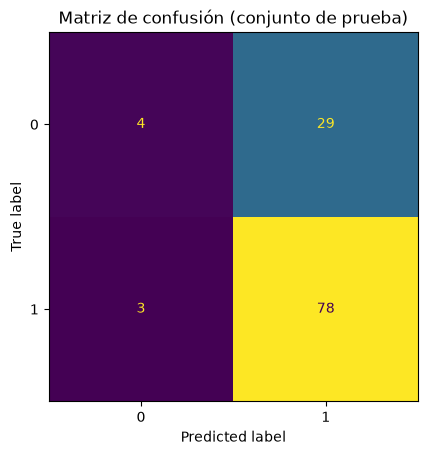

In [17]:
def calcular_metricas(particion_x, particion_y):
    """Retorna las métricas del pipeline sobre una partición."""
    pred = best_data_model_pipeline.predict(particion_x)
    proba = best_data_model_pipeline.predict_proba(particion_x)[:, 1]
    return {
        "recall": recall_score(particion_y, pred),
        "precision": precision_score(particion_y, pred),
        "f1": f1_score(particion_y, pred),
        "auc": roc_auc_score(particion_y, proba),
    }


# comparación de métricas: una brecha grande indica sobreajuste
comparacion_metricas = pd.DataFrame(
    {
        "entrenamiento": calcular_metricas(x_train, y_train),
        "prueba": calcular_metricas(x_test, y_test),
    }
).round(3)
print(comparacion_metricas)

# reporte de clasificación en prueba
print(classification_report(y_test, best_data_model_pipeline.predict(x_test), digits=3))

# matriz de confusión en prueba
ConfusionMatrixDisplay.from_estimator(best_data_model_pipeline, x_test, y_test, colorbar=False)
plt.title("Matriz de confusión (conjunto de prueba)")
plt.show()

## 💾 Guardar el modelo

In [18]:
DATA_MODEL = Path.cwd().resolve().parents[1] / "models"

In [19]:
# guardar el modelo con joblib
dump(
    best_data_model_pipeline,
    DATA_MODEL / "experiments/pacientes_higado_random_forest-v1.joblib",
    protocol=5,
)

['/workspaces/Pacientes_porblemas_higado_india/models/experiments/pacientes_higado_random_forest-v1.joblib']

In [20]:
# Evidencia del impacto del leakage + comparación con el baseline, todo junto.
from sklearn.metrics import average_precision_score, confusion_matrix

# ANTES: misma búsqueda (con scoring=f1_macro para comparación justa) sobre el split viejo
grid_antes = RandomizedSearchCV(
    data_model_pipeline,
    {
        "model__max_depth": [4, 5, 7, 9, 10],
        "model__max_features": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
        "model__criterion": ["gini", "entropy"],
    },
    cv=5,
    scoring="f1_macro",
    n_jobs=8,
    random_state=SEED,
).fit(x_train_leaky, y_train_leaky)
modelo_antes = grid_antes.best_estimator_


def _metricas_clave(y_true, y_pred, y_score):
    return {
        "recall clase 1": recall_score(y_true, y_pred),
        "recall clase 0 (sanos)": recall_score(y_true, y_pred, pos_label=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "roc_auc": roc_auc_score(y_true, y_score),
        "average_precision": average_precision_score(y_true, y_score),
    }


resultados_antes_despues_05 = pd.DataFrame(
    {
        "ANTES (leaky, f1_macro)": _metricas_clave(
            y_test_leaky,
            modelo_antes.predict(x_test_leaky),
            modelo_antes.predict_proba(x_test_leaky)[:, 1],
        ),
        "DESPUÉS (v2, f1_macro)": _metricas_clave(y_test, y_pred, y_proba),
        "baseline heurístico (01)": {
            "recall clase 1": 0.926,
            "recall clase 0 (sanos)": 0.588,
            "f1_macro": 0.659,
            "roc_auc": 0.815,
            "average_precision": 0.892,
        },
    }
).round(3)
display(resultados_antes_despues_05)
print(f"Hiperparámetros ANTES: {grid_antes.best_params_}")
print(f"Hiperparámetros DESPUÉS: {grid_search.best_params_}")
print("\nMatriz de confusión en test v2 (filas = real, columnas = predicción):")
print(confusion_matrix(y_test, y_pred))

,"ANTES (leaky, f1_macro)","DESPUÉS (v2, f1_macro)",baseline heurístico (01)
recall clase 1,0.880,0.963,0.926
recall clase 0 (sanos),0.147,0.121,0.588
f1_macro,0.497,0.515,0.659
roc_auc,0.747,0.813,0.815
average_precision,0.895,0.922,0.892


Hiperparámetros ANTES: {'model__max_features': 5, 'model__max_depth': 9, 'model__criterion': 'entropy'}
Hiperparámetros DESPUÉS: {'model__max_features': 6, 'model__max_depth': 10, 'model__criterion': 'gini'}

Matriz de confusión en test v2 (filas = real, columnas = predicción):
[[ 4 29]
 [ 3 78]]


In [21]:
# Prueba de permutación (lección del notebook 02): etiquetas de train barajadas, X intacta.
resultados_permutacion_05 = []
for seed in [0, 1, 2, 3, 4]:
    y_train_perm = pd.Series(
        np.random.default_rng(seed).permutation(y_train.values), index=y_train.index
    )
    pipe_perm = data_model_pipeline.__class__(steps=data_model_pipeline.steps).fit(
        x_train, y_train_perm
    )
    y_pred_perm = pipe_perm.predict(x_test)
    y_score_perm = pipe_perm.predict_proba(x_test)[:, 1]
    resultados_permutacion_05.append(
        {
            "seed": seed,
            "recall clase 1": recall_score(y_test, y_pred_perm),
            "recall clase 0": recall_score(y_test, y_pred_perm, pos_label=0),
            "f1_macro": f1_score(y_test, y_pred_perm, average="macro"),
            "roc_auc": roc_auc_score(y_test, y_score_perm),
        }
    )

permutacion_df_05 = pd.DataFrame(resultados_permutacion_05).set_index("seed").round(3)
display(permutacion_df_05)
print(
    f"Rango con etiquetas barajadas: roc_auc "
    f"[{permutacion_df_05.roc_auc.min():.3f}, {permutacion_df_05.roc_auc.max():.3f}] | "
    f"f1_macro [{permutacion_df_05.f1_macro.min():.3f}, {permutacion_df_05.f1_macro.max():.3f}]"
)

,recall clase 1,recall clase 0,f1_macro,roc_auc
seed,,,,
0,0.926,0.061,0.450,0.403
1,0.926,0.091,0.475,0.510
2,0.926,0.061,0.450,0.469
3,0.901,0.152,0.510,0.548
4,0.926,0.242,0.585,0.605


Rango con etiquetas barajadas: roc_auc [0.403, 0.605] | f1_macro [0.450, 0.585]


In [22]:
# Banderas de calidad A/G: verificación de que no son predictoras ni se excluyen.
FLAGS_AG_INCONSISTENTE = [267, 415, 484, 491, 548, 575]
FLAGS_AG_BORDERLINE = [33, 208, 273, 301, 304, 465, 560]

en_train = [i for i in FLAGS_AG_INCONSISTENTE + FLAGS_AG_BORDERLINE if i in x_train.index]
en_test = [i for i in FLAGS_AG_INCONSISTENTE + FLAGS_AG_BORDERLINE if i in x_test.index]
sin_banderas = [c for c in x_train.columns if "flag" in c.lower()]
print(f"Columnas predictoras: {len(x_train.columns)} | con 'flag': {sin_banderas or 'ninguna'}")
print(f"Filas marcadas: {len(en_train)}/13 en train, {len(en_test)}/13 en test — ninguna excluida")

y_pred_marcadas = pd.Series(best_data_model_pipeline.predict(x_train), index=x_train.index)
errores_marcadas = int((y_pred_marcadas.loc[en_train] != y_train.loc[en_train]).sum())
print(f"Errores del RF tuneado sobre las 13 filas marcadas: {errores_marcadas}")

Columnas predictoras: 10 | con 'flag': ninguna
Filas marcadas: 13/13 en train, 0/13 en test — ninguna excluida
Errores del RF tuneado sobre las 13 filas marcadas: 0


---

## Corrección de leakage aplicada — ver PR #24 (feat_eng) para el detalle de la causa raíz

Este notebook de validación trabaja ahora sobre los splits corregidos
`x_train_v2`/`x_test_v2` (452/114 pacientes, checksums verificados), con la búsqueda de
hiperparámetros usando `scoring="f1_macro"` —consistente con los notebooks 02, 03 y
04— y el preprocesador reajustándose dentro de cada fold por formar parte del
`Pipeline`. El test v2 se usa una sola vez, al final.

### Lo que aprendimos validando

La lección incómoda de este notebook es que los chequeos de integridad solo valen lo
que vale su definición de "duplicado": la verificación original de registros
compartidos entre train y test daba cero y aun así había siete pacientes en ambos
conjuntos, porque las copias casi exactas no cuentan para un `merge`. Sobre los datos
v2, los mismos chequeos sí respaldan lo que afirman. Y en la lectura de resultados
sigue mandando el desbalance: con 71 % de positivos, el recall de la clase 1 y el
accuracy se inflan solos; las cifras comparables son f1_macro y las métricas de
ranking, con el average_precision leído contra la prevalencia de 0,71.

### Frente al baseline del notebook 01

La heurística clínica (recall 0,926, f1_macro 0,659, roc_auc 0,815, AP 0,892) sigue
siendo la referencia — un baseline informado por dominio, no un piso trivial. La
tabla de arriba deja la comparación en números, sin interpretación forzada.

## 📖 Referencias

- <https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ks_2samp.html>
- <https://scikit-learn.org/stable/modules/model_evaluation.html>
- <https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html>
- Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems 2nd Edition - Aurélien Géron
- Dataset ILPD (Indian Liver Patient Dataset):
  <https://archive.ics.uci.edu/dataset/225/ilpd+indian+liver+patient+dataset>